In [ ]:
!pip install textgrid
import os
import json
import re
import ast
import textgrid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

  Preparing metadata (setup.py) ... done
  Created wheel for textgrid: filename=TextGrid-1.6.1-py3-none-any.whl size=10146 sha256=5768c0f4f89a7b1b109a2eefb4b7981923375fef599e910401019f4299f345c5
  Stored in directory: /root/.cache/pip/wheels/ce/86/7b/5766bd19fa4b4554667dd186e614b5a438ab14eec9c5a3642a
Successfully built textgrid


In [ ]:
# ==============================================================================
# 0. PUBLICATION-GRADE PLOT STYLING
# ==============================================================================
# Set Matplotlib to output text as TrueType for Adobe Illustrator/PDF tweaks
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 300  # High resolution for research papers
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [ ]:
import os

zip_file_path = "/content/mfa_output_london.zip"
extract_directory = "/content/"

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_directory):
    os.makedirs(extract_directory)

# Unzip the file using a shell command
!unzip -o "{zip_file_path}" -d "{extract_directory}"

print(f"Successfully unzipped '{zip_file_path}' to '{extract_directory}'")

Archive:  /content/mfa_output_london.zip
   creating: /content/content/mfa_output/
  inflating: /content/content/mfa_output/j-coo4-m5.TextGrid  
  inflating: /content/content/mfa_output/j-coo5-f7.TextGrid  
  inflating: /content/content/mfa_output/j-dec7-m4.TextGrid  
  inflating: /content/content/mfa_output/j-dec1-f2.TextGrid  
  inflating: /content/content/mfa_output/j-dqu1-f4.TextGrid  
  inflating: /content/content/mfa_output/j-dec1-m5.TextGrid  
  inflating: /content/content/mfa_output/j-coo3-m2.TextGrid  
  inflating: /content/content/mfa_output/j-coo3-m4.TextGrid  
  inflating: /content/content/mfa_output/j-coo3-f6.TextGrid  
  inflating: /content/content/mfa_output/j-coo1-m2.TextGrid  
  inflating: /content/content/mfa_output/j-dec2-f1.TextGrid  
  inflating: /content/content/mfa_output/j-coo4-f2.TextGrid  
  inflating: /content/content/mfa_output/j-dqu3-f1.TextGrid  
  inflating: /content/content/mfa_output/j-yno2-m4.TextGrid  
  inflating: /content/content/mfa_output/j-yno3-f

In [ ]:
import os

zip_file_path = "/content/london_pms.zip"
extract_directory = "/content/"

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_directory):
    os.makedirs(extract_directory)

# Unzip the file using a shell command
!unzip -o "{zip_file_path}" -d "{extract_directory}"

print(f"Successfully unzipped '{zip_file_path}' to '{extract_directory}'")

Archive:  /content/london_pms.zip
   creating: /content/london_pms/
  inflating: /content/london_pms/j-coo1-f3.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-coo1-f3.pms.txt  
  inflating: /content/london_pms/j-dqu3-m1.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-dqu3-m1.pms.txt  
  inflating: /content/london_pms/j-dec1-f1.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-dec1-f1.pms.txt  
  inflating: /content/london_pms/j-coo4-f2.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-coo4-f2.pms.txt  
  inflating: /content/london_pms/j-dqu1-f2.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-dqu1-f2.pms.txt  
  inflating: /content/london_pms/j-dec3-m2.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-dec3-m2.pms.txt  
  inflating: /content/london_pms/j-dec6-m3.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-dec6-m3.pms.txt  
  inflating: /content/london_pms/j-whq3-f3.pms.txt  
  inflating: /content/__MACOSX/london_pms/._j-whq3-f3.pms.tx

In [ ]:
# ==============================================================================
# 1. PATH & DIRECTORY CONFIGURATION
# ==============================================================================
TEXT_PREDICTIONS_FILE = "/content/llm_predictions_london.json"
SPEECH_PREDICTIONS_FILE = "/content/speech_llm_predictions_london.json"
TEXTGRID_DIR = "/content/mfa_output"
PMS_DIR = "/content/london_pms"

# IViE Corpus Grammatical Intent Mapping
INTENT_MAP = {
    "sta": "Statement", "dec": "Statement", "s": "Statement",
    "que": "Question", "dqu": "Question", "q": "Question",
    "inv": "Question", "yno": "Question", "i": "Question",
    "whq": "Question", "w": "Question",
    "coo": "Choice", "c": "Choice"
}

In [ ]:
# ==============================================================================
# 2. DATA PARSING & CLEANING LAYER
# ==============================================================================
def safely_parse_prediction(raw_output):
    if isinstance(raw_output, dict):
        return raw_output
    if not isinstance(raw_output, str):
        return {}
    cleaned = raw_output.replace("```json", "").replace("```", "").strip()
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        try:
            return ast.literal_eval(cleaned)
        except (ValueError, SyntaxError):
            return {}

In [ ]:
# ==============================================================================
# 3. GROUND TRUTH ALIGNMENT LAYER
# ==============================================================================
def get_ground_truth_intent(filename):
    """Extracts the intent from the IViE 5-character naming convention."""
    # IViE format: 1st char = intent, 2nd = sentence index, 3rd = dialect, 4/5 = speaker
    if len(filename) >= 5:
        code = filename[0].lower()
        return INTENT_MAP.get(code, "Unknown")
    return "Unknown"

def get_sentence_words_and_emphasis(base_name):
    """Extracts word tokens with timing intervals and maps emphasis labels."""
    pms_file = os.path.join(PMS_DIR, f"{base_name}.pms.txt")
    tg_file = os.path.join(TEXTGRID_DIR, f"{base_name}.TextGrid")

    all_words = []
    emphasized_words = []
    emphasis_timestamps = []

    if os.path.exists(pms_file):
        with open(pms_file, "r") as f:
            for line in f.readlines():
                if line.startswith("#") or any(k in line for k in ["signal", "type", "comment", "color", "font", "separator", "nfields"]):
                    continue
                parts = line.strip().split()
                if len(parts) >= 3:
                    try:
                        time = float(parts[0])
                        if parts[2].upper() in ['P', 'S']:
                            emphasis_timestamps.append(time)
                    except ValueError:
                        pass

    if os.path.exists(tg_file):
        try:
            tg = textgrid.TextGrid.fromFile(tg_file)
            word_tier = next((t for t in tg.tiers if t.name.lower() in ["words", "word"]), None)
            if word_tier:
                for interval in word_tier:
                    mark = interval.mark.strip()
                    if not mark:
                        continue
                    clean_word = mark.strip('.,!? "\'').lower()
                    all_words.append({
                        "word": clean_word,
                        "minTime": interval.minTime,
                        "maxTime": interval.maxTime
                    })
                    for p_time in emphasis_timestamps:
                        if interval.minTime <= p_time <= interval.maxTime:
                            if clean_word not in emphasized_words:
                                emphasized_words.append(clean_word)
        except Exception:
            pass

    return all_words, emphasized_words

In [ ]:
# ==============================================================================
# 4. EVALUATION & EXTRACTION ENGINE
# ==============================================================================
def run_scientific_evaluation(predictions_file_path):
    if not os.path.exists(predictions_file_path):
        return None

    with open(predictions_file_path, "r") as f:
        raw_data = json.load(f)

    sentence_data_entries = []
    all_true_tokens, all_pred_tokens = [], []
    intents_true, intents_pred = [], []

    for base_name, raw_prediction in raw_data.items():
        prediction = safely_parse_prediction(raw_prediction)
        if not prediction:
            continue

        # Process Intents
        gt_intent = get_ground_truth_intent(base_name)
        llm_intent = prediction.get("predicted_intent", "Unknown").capitalize()
        intents_true.append(gt_intent)
        intents_pred.append(llm_intent)

        # Process Emphasis
        pms_file_path = os.path.join(PMS_DIR, f"{base_name}.pms.txt")
        if os.path.exists(pms_file_path):
            full_intervals, gt_emp_words = get_sentence_words_and_emphasis(base_name)
            if not full_intervals:
                continue

            raw_llm_words = prediction.get("predicted_emphasis_words", [])
            if not isinstance(raw_llm_words, list):
                raw_llm_words = []
            llm_emp_words = [str(w).strip('.,!? "\'').lower() for w in raw_llm_words]

            sent_true, sent_pred = [], []
            evaluated_vocab = set(gt_emp_words + llm_emp_words)
            for word in evaluated_vocab:
                sent_true.append(1 if word in gt_emp_words else 0)
                sent_pred.append(1 if word in llm_emp_words else 0)

            all_true_tokens.extend(sent_true)
            all_pred_tokens.extend(sent_pred)

            sentence_data_entries.append({
                "base_name": base_name,
                "word_count": len(full_intervals),
                "intervals": full_intervals,
                "gt_emphasis": gt_emp_words,
                "pred_emphasis": llm_emp_words,
                "sent_true": sent_true,
                "sent_pred": sent_pred
            })

    global_prec = precision_score(all_true_tokens, all_pred_tokens, zero_division=0) * 100
    global_rec = recall_score(all_true_tokens, all_pred_tokens, zero_division=0) * 100
    global_f1 = f1_score(all_true_tokens, all_pred_tokens, zero_division=0) * 100

    return {
        "precision": global_prec, "recall": global_rec, "f1": global_f1,
        "sentences": sentence_data_entries,
        "intents_true": intents_true,
        "intents_pred": intents_pred
    }

print("Running structural analytical evaluations...")
text_analysis = run_scientific_evaluation(TEXT_PREDICTIONS_FILE)
speech_analysis = run_scientific_evaluation(SPEECH_PREDICTIONS_FILE)

Running structural analytical evaluations...


In [ ]:
import os

zip_file_path = "/content/js_new.zip"
extract_directory = "/content/"

# Create the extraction directory if it doesn't exist
if not os.path.exists(extract_directory):
    os.makedirs(extract_directory)

# Unzip the file using a shell command
!unzip -o "{zip_file_path}" -d "{extract_directory}"

print(f"Successfully unzipped '{zip_file_path}' to '{extract_directory}'")

Archive:  /content/js_new.zip
   creating: /content/js_new/
  inflating: /content/__MACOSX/._js_new  
  inflating: /content/js_new/j-coo4-m5.wav  
  inflating: /content/__MACOSX/js_new/._j-coo4-m5.wav  
  inflating: /content/js_new/j-dec5-m4.wav  
  inflating: /content/__MACOSX/js_new/._j-dec5-m4.wav  
  inflating: /content/js_new/j-whq2-m5.wav  
  inflating: /content/__MACOSX/js_new/._j-whq2-m5.wav  
  inflating: /content/js_new/j-yno3-f2.wav  
  inflating: /content/__MACOSX/js_new/._j-yno3-f2.wav  
  inflating: /content/js_new/j-dec1-f7.wav  
  inflating: /content/__MACOSX/js_new/._j-dec1-f7.wav  
  inflating: /content/js_new/j-coo2-f3.wav  
  inflating: /content/__MACOSX/js_new/._j-coo2-f3.wav  
  inflating: /content/js_new/j-yno1-f7.wav  
  inflating: /content/__MACOSX/js_new/._j-yno1-f7.wav  
  inflating: /content/js_new/j-dec3-f2.wav  
  inflating: /content/__MACOSX/js_new/._j-dec3-f2.wav  
  inflating: /content/js_new/j-dqu3-m2.wav  
  inflating: /content/__MACOSX/js_new/._j-dqu

In [ ]:
from pathlib import Path
import shutil
import os
import librosa
import soundfile as sf

# Define your source folders (Assumes they are already unzipped in /content/)
AUDIO_SOURCE_DIR = Path("/content/js_new")

# MFA requires audio and text to be in the exact same directory
MFA_INPUT_DIR = Path("/content/mfa_input")

MFA_INPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Standardizing audio and copying to MFA staging directory...")

# 1. Process and move audio files (Resample to 16kHz, Mono)
for audio_file in AUDIO_SOURCE_DIR.glob("*"):
    if audio_file.suffix.lower() in [".wav", ".mp3", ".flac", ".m4a"]:
        audio, sr = librosa.load(audio_file, sr=16000, mono=True)
        output_file = MFA_INPUT_DIR / f"{audio_file.stem}.wav"
        sf.write(output_file, audio, 16000, subtype="PCM_16")

Standardizing audio and copying to MFA staging directory...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 75.3 MB/s eta 0:00:00
Extracting acoustic features and mapping ground-truth stress labels...
Successfully extracted 648 valid voiced words for clustering.
Found 304 stressed words and 344 unstressed words.
Plot saved as 'real_acoustic_pca_clustering.pdf'


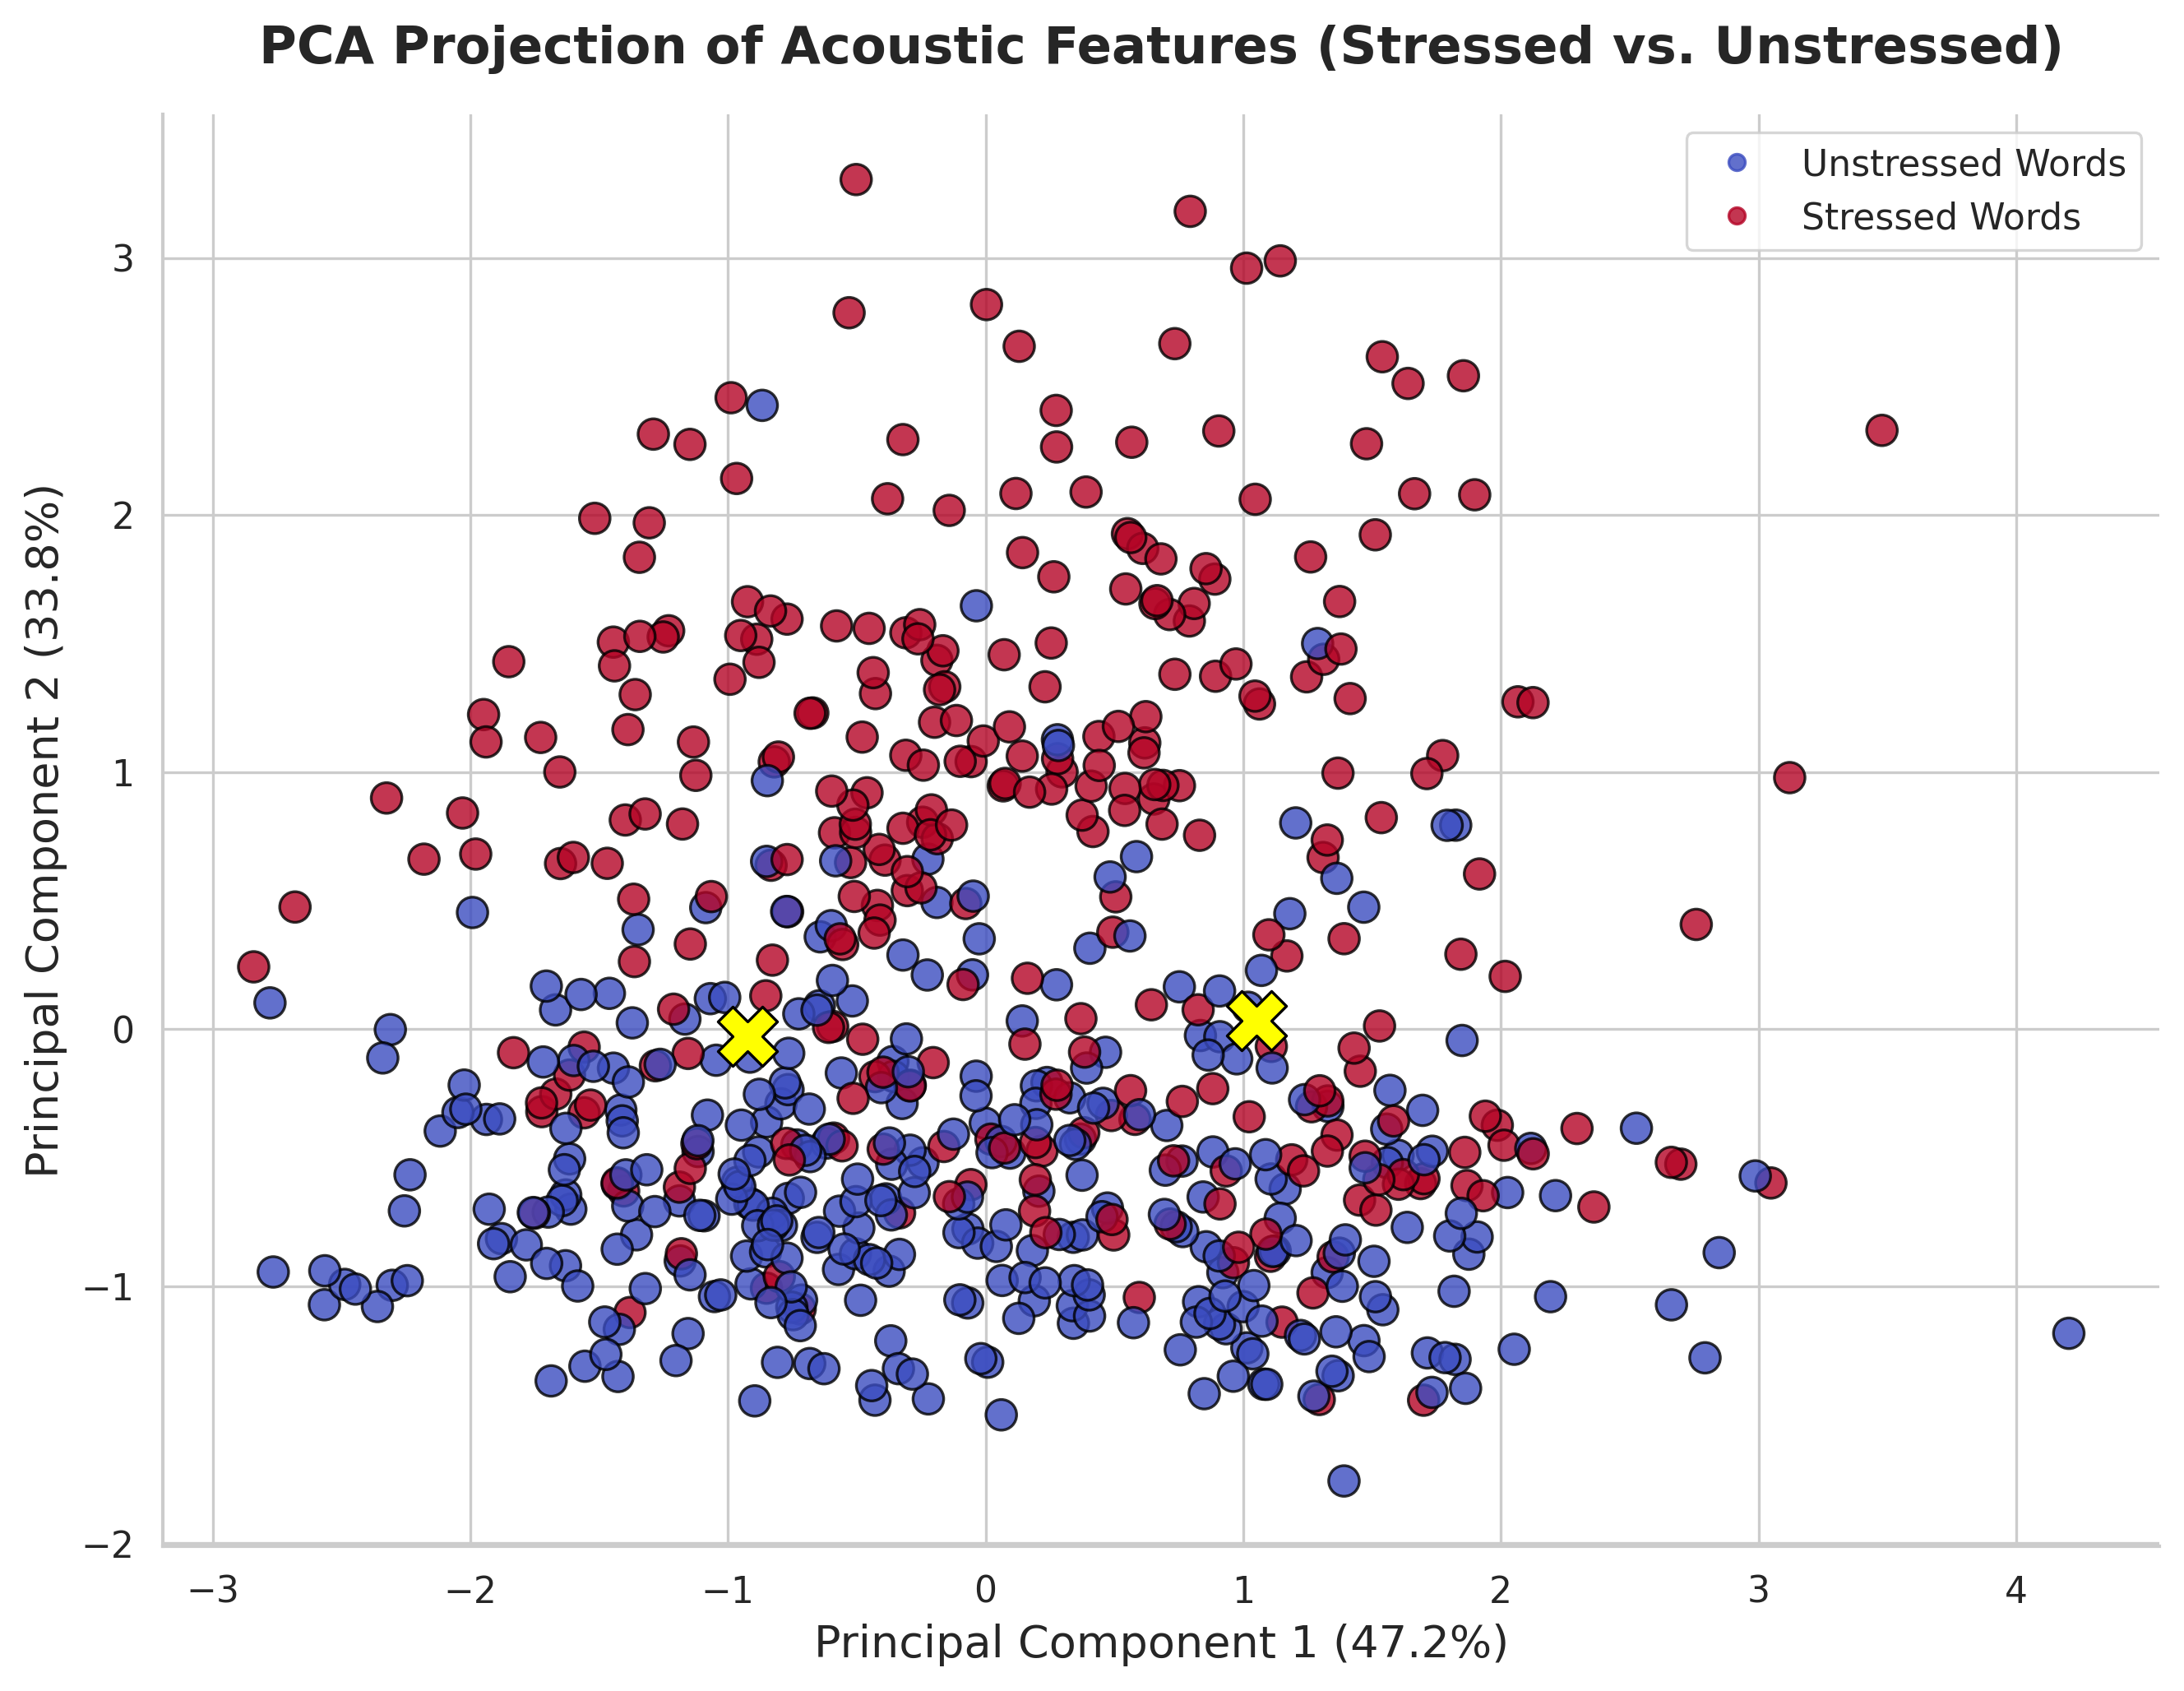

In [ ]:
# ==============================================================================
# 5. ACOUSTIC FEATURE EXTRACTION & GROUND TRUTH MAPPING
# ==============================================================================
!pip install praat-parselmouth
import parselmouth
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# UPDATE THIS PATH to where your raw .wav files are stored
AUDIO_DIR = "/content/mfa_input"

print("Extracting acoustic features and mapping ground-truth stress labels...")

features_list = []
y_true_list = []
word_labels = []

# Iterate through the TextGrids in your specified directory
for tg_file in sorted(os.listdir(TEXTGRID_DIR)):
    if not tg_file.endswith(".TextGrid"):
        continue

    base_name = os.path.splitext(tg_file)[0]
    wav_file = os.path.join(AUDIO_DIR, f"{base_name}.wav")
    pms_file = os.path.join(PMS_DIR, f"{base_name}.pms.txt")

    # Skip if we are missing the corresponding audio or pms file
    if not os.path.exists(wav_file) or not os.path.exists(pms_file):
        continue

    # 1. Parse PMS for Prominence timestamps
    emphasis_timestamps = []
    with open(pms_file, "r") as f:
        for line in f.readlines():
            if line.startswith("#") or any(k in line for k in ["signal", "type", "comment", "color", "font", "separator", "nfields"]):
                continue
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2].upper() in ['P', 'S']:
                try:
                    emphasis_timestamps.append(float(parts[0]))
                except ValueError:
                    pass

    # 2. Parse Audio and TextGrid
    try:
        tg = textgrid.TextGrid.fromFile(os.path.join(TEXTGRID_DIR, tg_file))
        snd = parselmouth.Sound(wav_file)
    except Exception as e:
        print(f"Error loading files for {base_name}: {e}")
        continue

    word_tier = next((t for t in tg.tiers if t.name.lower() in ["words", "word"]), None)
    if not word_tier:
        continue

    # 3. Extract word-level metrics and align with labels
    for interval in word_tier:
        word = interval.mark.strip()
        if not word:
            continue

        start, end = interval.minTime, interval.maxTime
        duration = (end - start) * 1000  # Convert to ms

        # Ground Truth Labeling: Check if a 'P' timestamp falls inside this word's duration
        is_stressed = 0
        for p_time in emphasis_timestamps:
            if start <= p_time <= end:
                is_stressed = 1
                break

        # Acoustic Extraction
        try:
            word_snd = snd.extract_part(from_time=start, to_time=end)
            w_pitch = word_snd.to_pitch()
            w_intensity = word_snd.to_intensity()

            p_vals = w_pitch.selected_array["frequency"]
            pitch_val = np.mean(p_vals[p_vals > 0]) if len(p_vals[p_vals > 0]) > 0 else np.nan
            int_val = np.nanmax(w_intensity.values) if w_intensity.values.size > 0 else np.nan

            # Filter out NaNs (unvoiced sounds) so K-Means doesn't crash
            if not np.isnan(pitch_val) and not np.isnan(int_val):
                features_list.append([pitch_val, int_val, duration])
                y_true_list.append(is_stressed)
                word_labels.append(word)

        except Exception:
            # Skip words that Praat fails to process (e.g., too short)
            continue

# Convert to Scikit-Learn friendly numpy arrays
X = np.array(features_list)
y_true = np.array(y_true_list)

print(f"Successfully extracted {X.shape[0]} valid voiced words for clustering.")
print(f"Found {np.sum(y_true)} stressed words and {len(y_true) - np.sum(y_true)} unstressed words.")


# ==============================================================================
# 6. VISUALIZATION: ACOUSTIC FEATURE CLUSTERING (PCA & K-MEANS)
# ==============================================================================
if X.shape[0] > 0:
    plt.figure(figsize=(9, 7))

    # Standardize the features before PCA (Highly recommended for acoustic data)
    from sklearn.preprocessing import StandardScaler
    X_scaled = StandardScaler().fit_transform(X)

    # Project 3D Acoustic Features into 2D Space
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Apply K-Means
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)

    # Plot the real data, colored by ground-truth labels
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=80, edgecolors='black', alpha=0.8)

    # Plot K-Means Centroids
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='yellow', s=300, marker='X', edgecolors='black', label='K-Means Centroids')

    # Formatting
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=13)
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=13)
    plt.title('PCA Projection of Acoustic Features (Stressed vs. Unstressed)', fontsize=15, fontweight='bold', pad=15)

    # Legend formatting
    handles, _ = scatter.legend_elements()
    # Check if we have both classes present in the data for the legend
    legend_labels = []
    if 0 in y_true: legend_labels.append('Unstressed Words')
    if 1 in y_true: legend_labels.append('Stressed Words')

    plt.legend(handles, legend_labels, loc='upper right', frameon=True)
    sns.despine()
    plt.tight_layout()

    plt.savefig("real_acoustic_pca_clustering.pdf")
    print("Plot saved as 'real_acoustic_pca_clustering.pdf'")
    plt.show()
else:
    print("Not enough valid data extracted to generate the plot. Check your audio directory and TextGrid alignments.")

DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations
DEBUG - Read Text: 'are you growing limes or lemons' --> Categorized As: Coordinations


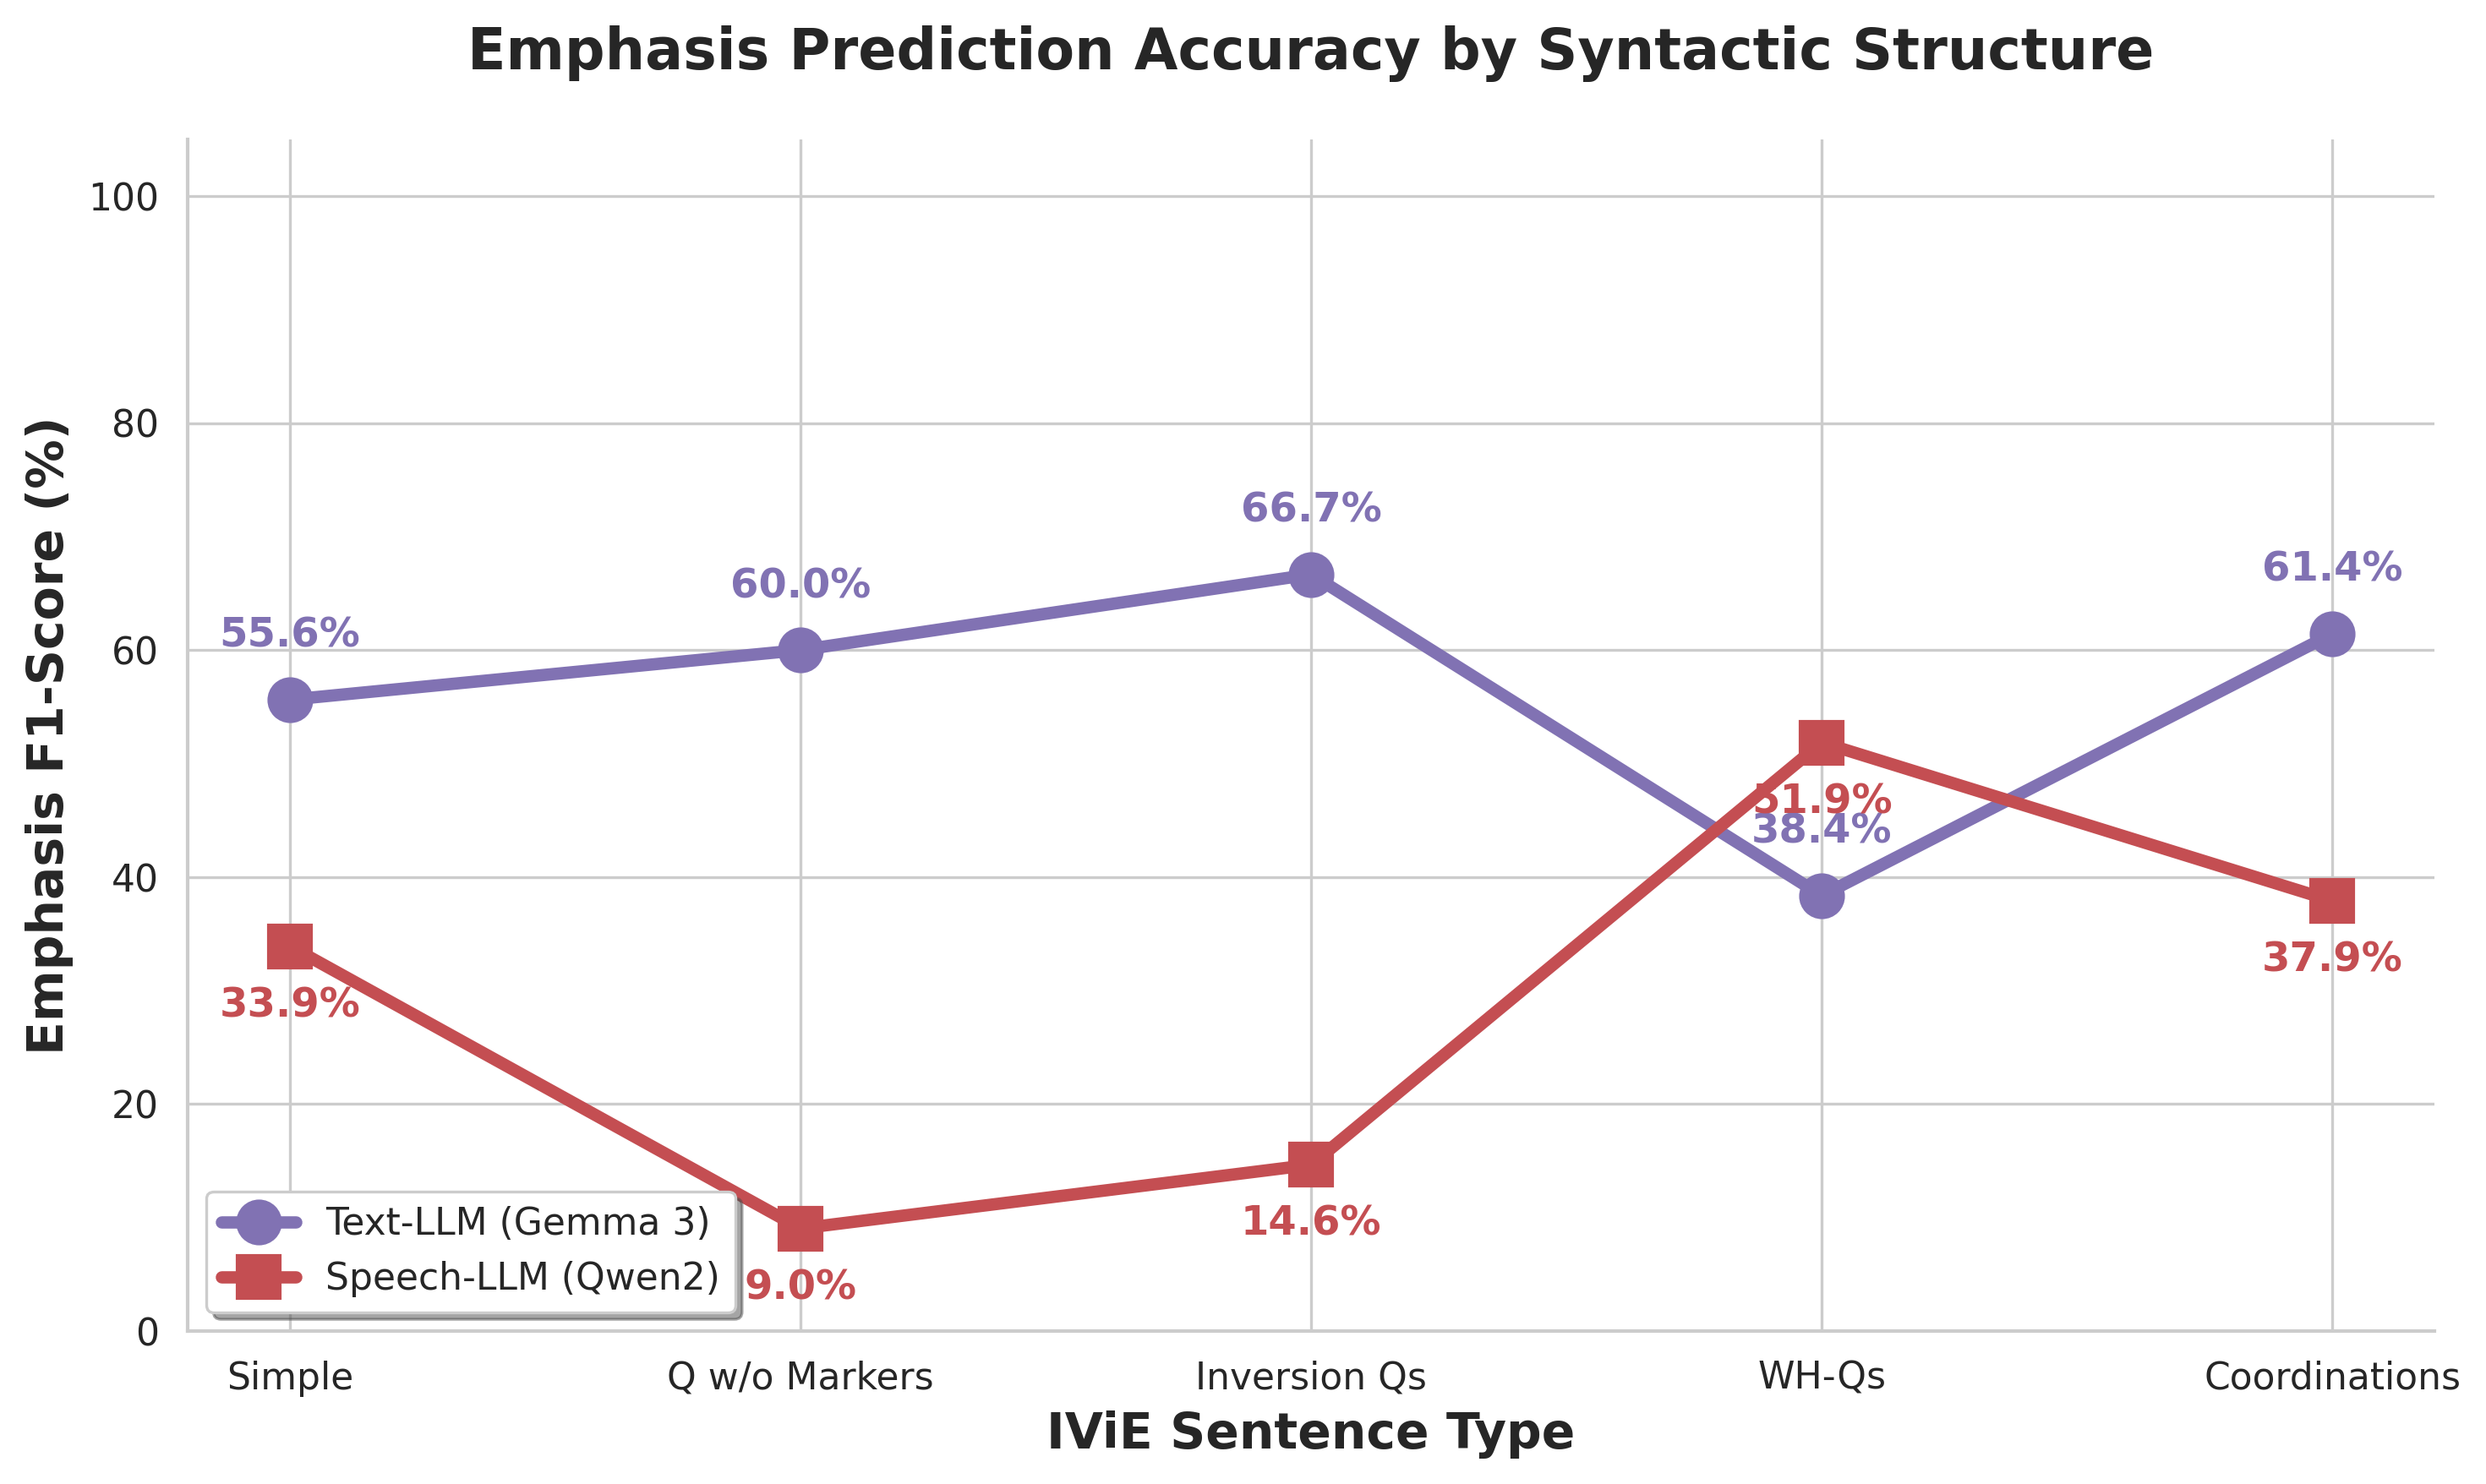

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

# --------------------------------------------------------------------------
# VISUALIZATION 3: METRIC PERFORMANCE BY SENTENCE TYPE (IViE CORPUS)
# --------------------------------------------------------------------------

def categorize_sentence(text):
    """Categorizes an IViE corpus sentence based on its grammatical structure."""
    if not text:
        return 'Simple Statements'

    text_lower = text.strip().lower()

    # ---------------------------------------------------------
    # NEW: EXACT MATCH for Questions without Markers
    # (Bypasses the fact that MFA stripped the '?')
    # ---------------------------------------------------------
    q_wo_markers = [
        "he is on the lilo",
        "you remembered the lillies",
        "you live in ealing"
    ]
    if any(q in text_lower for q in q_wo_markers):
        return 'Q w/o Markers'

    # 1. Coordinations
    if " or " in text_lower:
        return 'Coordinations'

    # 2. Questions (Checks starting words)
    wh_words = ('where', 'when', 'why', 'who', 'what', 'how')
    aux_words = ('may', 'will', 'is', 'are', 'did', 'do', 'can', 'could', 'should', 'would', 'has', 'have')

    if text_lower.startswith(wh_words):
        return 'WH-Questions'
    elif text_lower.startswith(aux_words):
        return 'Inversion Questions'

    # 3. Default to Simple Statements
    return 'Simple Statements'

def calculate_type_f1(entries):
    categories = ['Simple Statements', 'Q w/o Markers', 'Inversion Questions', 'WH-Questions', 'Coordinations']
    bins = {cat: [] for cat in categories}

    # Debug flag so we only print the first few sentences to the console
    debug_count = 0

    for e in entries:
        # NOTE: If your raw text is NOT stored under 'text', change the string below!
        # If your text is only stored in the 'intervals' list from MFA, we rebuild it:
        if 'text' in e:
            sentence_text = e['text']
        elif 'intervals' in e:
            # Reconstruct the sentence from MFA word tiers if 'text' is missing
            sentence_text = " ".join([item['word'] for item in e['intervals']])
        else:
            sentence_text = ""

        if debug_count < 5:
            print(f"DEBUG - Read Text: '{sentence_text}' --> Categorized As: {categorize_sentence(sentence_text)}")
            debug_count += 1

        cat = categorize_sentence(sentence_text)
        bins[cat].append((e['sent_true'], e['sent_pred']))

    f1_scores = []
    for cat in categories:
        cat_true, cat_pred = [], []
        for t, p in bins[cat]:
            cat_true.extend(t)
            cat_pred.extend(p)

        if not cat_true:
            f1_scores.append(0.0)
        else:
            f1_scores.append(f1_score(cat_true, cat_pred, zero_division=0) * 100)

    return f1_scores

# Calculate scores
text_type_f1 = calculate_type_f1(text_analysis['sentences'])
speech_type_f1 = calculate_type_f1(speech_analysis['sentences'])

# --------------------------------------------------------------------------
# PLOTTING
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 6)) # Made slightly wider to accommodate category names

# Display labels for the X-axis
type_labels = ['Simple', 'Q w/o Markers', 'Inversion Qs', 'WH-Qs', 'Coordinations']

# Plotting the lines
plt.plot(type_labels, text_type_f1, marker='o', linewidth=3.5, markersize=12, label='Text-LLM (Gemma 3)', color='#8172B3')
plt.plot(type_labels, speech_type_f1, marker='s', linewidth=3.5, markersize=12, label='Speech-LLM (Qwen2)', color='#C44E52')

# Adding percentage annotations
for i, txt in enumerate(text_type_f1):
    plt.annotate(f'{txt:.1f}%', (type_labels[i], text_type_f1[i]), textcoords="offset points", xytext=(0,15), ha='center', fontweight='bold', color='#8172B3')
for i, txt in enumerate(speech_type_f1):
    plt.annotate(f'{txt:.1f}%', (type_labels[i], speech_type_f1[i]), textcoords="offset points", xytext=(0,-20), ha='center', fontweight='bold', color='#C44E52')

# Formatting the chart
min_f1 = min(min(text_type_f1), min(speech_type_f1))
plt.ylim(max(0, min_f1 - 15), 105)

plt.ylabel('Emphasis F1-Score (%)', fontsize=14, fontweight='bold')
plt.xlabel('IViE Sentence Type', fontsize=14, fontweight='bold')
plt.title('Emphasis Prediction Accuracy by Syntactic Structure', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower left', shadow=True)

sns.despine()
plt.tight_layout()
plt.savefig("syntactic_performance.pdf")
plt.show()

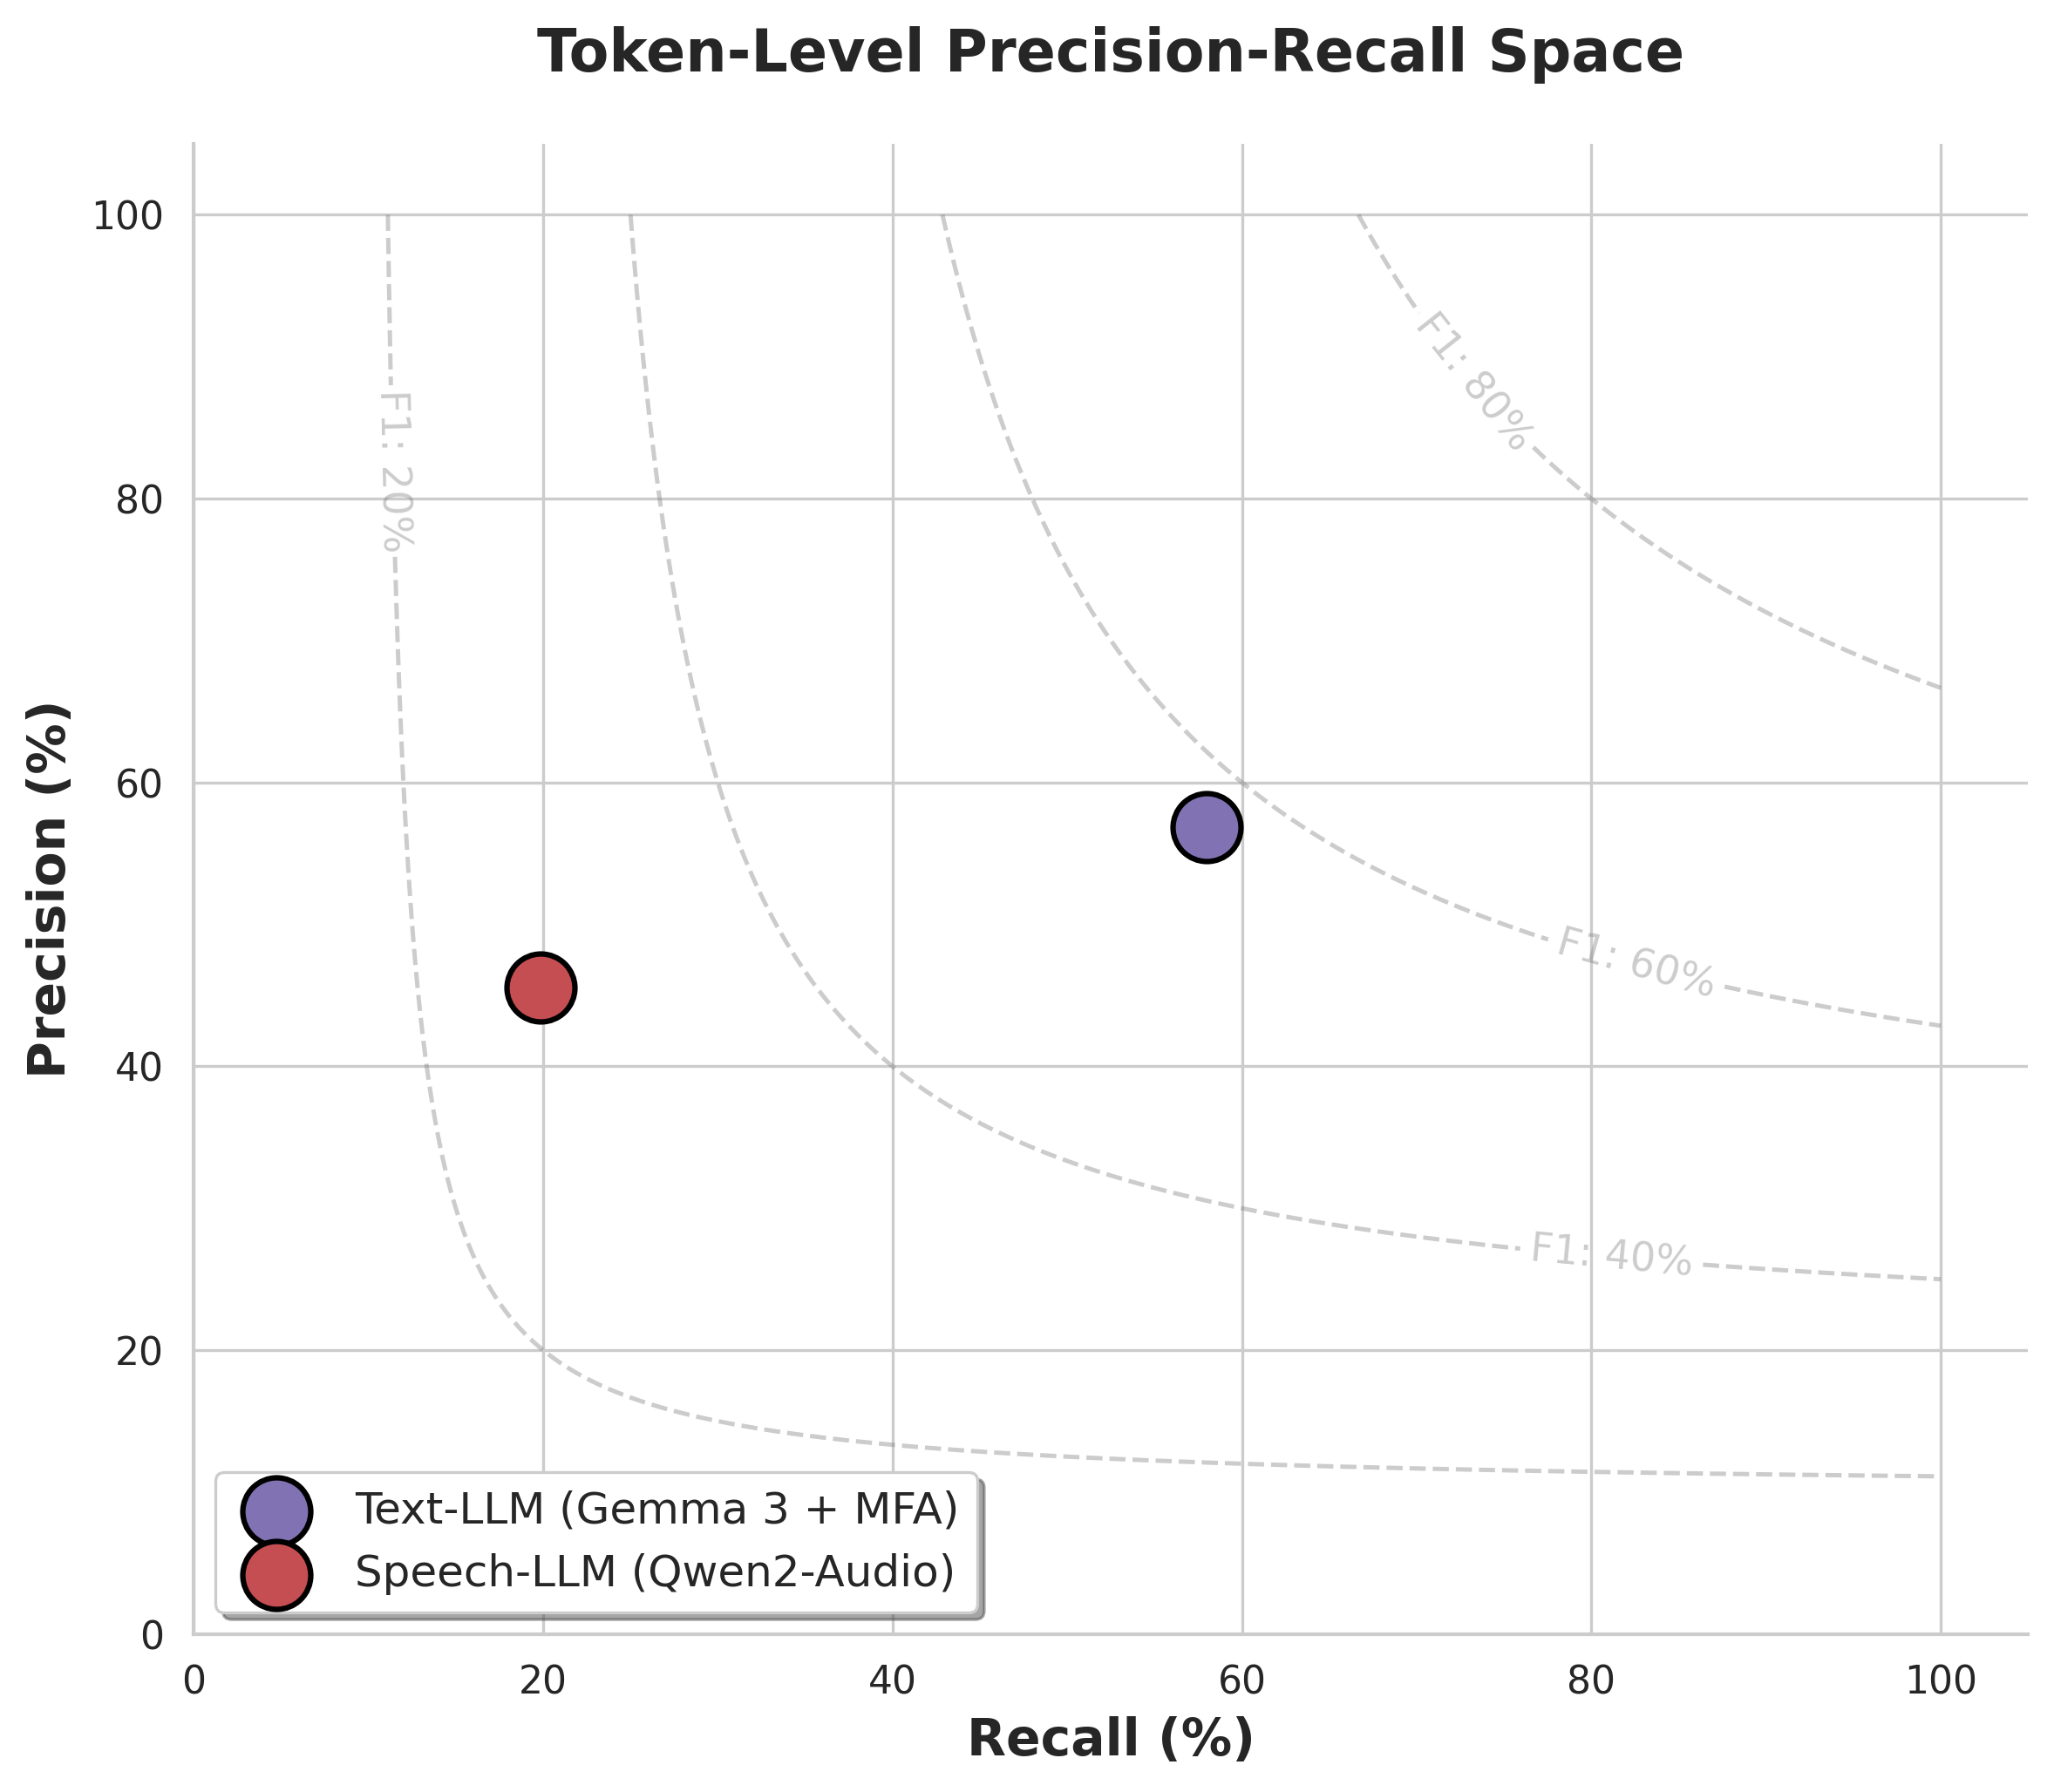

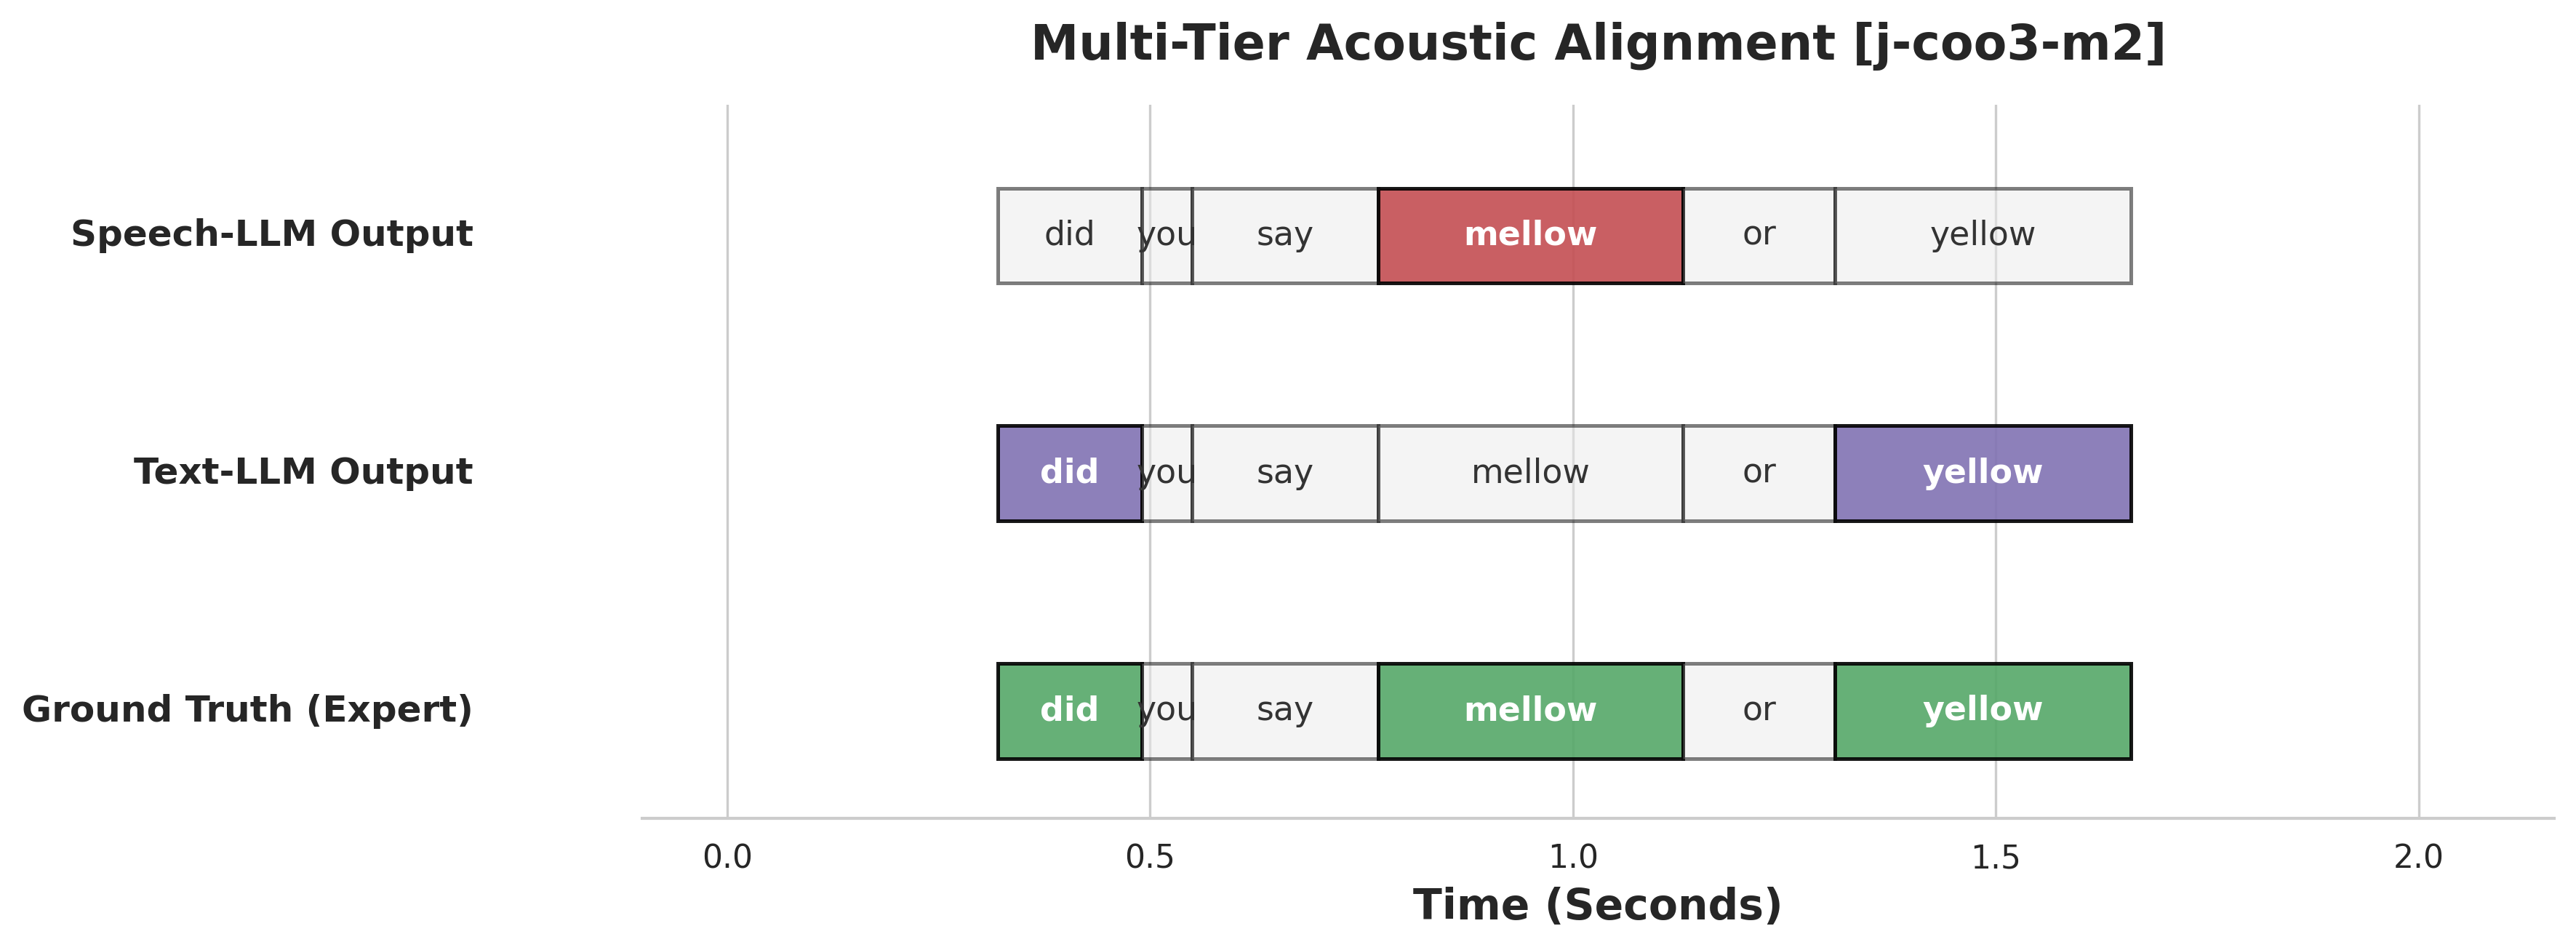

In [ ]:
# ==============================================================================
# 5. GENERATE SCIENTIFIC VISUALIZATIONS
# ==============================================================================
if text_analysis and speech_analysis:

    # --------------------------------------------------------------------------
    # VISUALIZATION 1: PRECISION-RECALL SPACE WITH ISO-F1 CONTOURS
    # --------------------------------------------------------------------------
    plt.figure(figsize=(8, 7))
    x_grid, y_grid = np.meshgrid(np.linspace(1, 100, 500), np.linspace(1, 100, 500))
    # LaTeX rendering for F1 formula background mathematically mapped
    f1_contours = 2 * (x_grid * y_grid) / (x_grid + y_grid)

    contours = plt.contour(x_grid, y_grid, f1_contours, levels=[20, 40, 60, 80], colors='gray', alpha=0.4, linestyles='dashed')
    plt.clabel(contours, inline=True, fmt='F1: %d%%', fontsize=11)

    plt.scatter(text_analysis['recall'], text_analysis['precision'], color='#8172B3', s=350, label='Text-LLM (Gemma 3 + MFA)', zorder=5, edgecolors='black', linewidths=1.5)
    plt.scatter(speech_analysis['recall'], speech_analysis['precision'], color='#C44E52', s=350, label='Speech-LLM (Qwen2-Audio)', zorder=5, edgecolors='black', linewidths=1.5)

    plt.xlim(0, 105)
    plt.ylim(0, 105)
    plt.xlabel('Recall (%)', fontsize=14, fontweight='bold')
    plt.ylabel('Precision (%)', fontsize=14, fontweight='bold')
    plt.title('Token-Level Precision-Recall Space', fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=1, fontsize=12, shadow=True)
    sns.despine()
    plt.tight_layout()
    plt.savefig("precision_recall_space.pdf")
    plt.show()

    # --------------------------------------------------------------------------
    # VISUALIZATION 2: QUALITATIVE ALIGNMENT TIER DIAGRAM
    # --------------------------------------------------------------------------
    if len(text_analysis['sentences']) > 0:
        target_name = "j-coo3-m2"
        sample_entry = next((s for s in text_analysis['sentences'] if s['base_name'] == target_name), None)
        sample_name = sample_entry['base_name']
        intervals = sample_entry['intervals']
        gt_emp = sample_entry['gt_emphasis']
        text_emp = sample_entry['pred_emphasis']

        speech_emp = next((s['pred_emphasis'] for s in speech_analysis['sentences'] if s['base_name'] == sample_name), [])

        fig, ax = plt.subplots(figsize=(12, 4.5))
        ax.set_title(f'Multi-Tier Acoustic Alignment [{sample_name}]', fontsize=16, fontweight='bold', pad=15)

        tiers = {'Ground Truth (Expert)': gt_emp, 'Text-LLM Output': text_emp, 'Speech-LLM Output': speech_emp}
        colors = {'Ground Truth (Expert)': '#55A868', 'Text-LLM Output': '#8172B3', 'Speech-LLM Output': '#C44E52'}

        for idx, (tier_name, detected_words) in enumerate(tiers.items()):
            y_pos = idx * 2
            ax.text(-0.3, y_pos + 0.4, tier_name, ha='right', va='center', fontweight='bold', fontsize=12)

            for item in intervals:
                w, start, end = item['word'], item['minTime'], item['maxTime']
                is_selected = w in detected_words
                rect = plt.Rectangle((start, y_pos), end - start, 0.8,
                                     facecolor=colors[tier_name] if is_selected else '#EAEAEA',
                                     edgecolor='black', linewidth=1.2, alpha=0.9 if is_selected else 0.5)
                ax.add_patch(rect)
                ax.text(start + (end - start)/2, y_pos + 0.4, w, ha='center', va='center',
                        fontsize=11, fontweight='bold' if is_selected else 'normal',
                        color='white' if is_selected else '#333333')

        ax.set_xlim(-0.1, max(i['maxTime'] for i in intervals) + 0.5)
        ax.set_ylim(-0.5, len(tiers) * 2 - 0.5)
        ax.set_xlabel('Time (Seconds)', fontsize=14, fontweight='bold')
        ax.get_yaxis().set_visible(False)
        sns.despine(left=True)
        plt.tight_layout()
        plt.savefig("tier_alignment.pdf")
        plt.show()

